# Compressible Euler Equations

## Generate Data & Fit Basis

#### Imports & Config

In [2]:
import sys
sys.path.append("../things")
sys.path.append("helpers")
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML

%matplotlib inline

import os
import numpy as np
import matplotlib.pyplot as plt
import opinf
import config
import utils
import step1_generate_data as step1
import random

Logging to log.log


In [3]:
training_span = (0, 0.08)
num_samples = 150
noiselevel = .03
num_regression_points = 250
numPODmodes = 6
num_pulls = 200
time_domain_test = np.linspace(0, training_span[-1], num_regression_points)

normalization = 1e-3

In [4]:
sampler = step1.trajectory(
    training_span,
    num_samples,
    noiselevel,
)
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, noiselevel)

print(true_states.shape, time_domain_sampled.shape, snapshots_sampled.shape)

generating training data...done in 0.80 s.
generating training data...done in 0.83 s.
(600, 401) (150,) (600, 150)


### Fit Basis

In [5]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

reducing noisy training states to 6 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (600, 150)
(600, 150) (600, 150)
(6, 401)
done in 0.09 s.


## Run Model GP Model and Visualize Results

### Bayesian GP

#### Define and Run Model

INFO:2025-09-11 08:57:37,961:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


Starting SVI optimization...
Iteration 0: loss = 5564.5737
Iteration 100: loss = 2232.0171
Iteration 200: loss = 1192.7609
Iteration 300: loss = 880.5441
Iteration 400: loss = 704.3813
Iteration 500: loss = 577.6111
Iteration 600: loss = 485.8825
Iteration 700: loss = 260.0476
Iteration 800: loss = 103.8965
Iteration 900: loss = -63.9933
Iteration 1000: loss = -201.5220
Iteration 1100: loss = -425.5102
Iteration 1200: loss = -469.8160
Iteration 1300: loss = -625.7582
Iteration 1400: loss = -670.3107
Iteration 1500: loss = -864.1299
Iteration 1600: loss = -888.2556
Iteration 1700: loss = -1048.5140
Iteration 1800: loss = -1091.2317
Iteration 1900: loss = -1098.6664
Iteration 2000: loss = -1164.7543
Iteration 2100: loss = -1146.5333
Iteration 2200: loss = -1216.0188
Iteration 2300: loss = -1253.2903
Iteration 2400: loss = -1280.9396
Iteration 2500: loss = -1302.7379
Iteration 2600: loss = -1305.4667
Iteration 2700: loss = -1348.5060
Iteration 2800: loss = -1286.4788
Iteration 2900: loss 

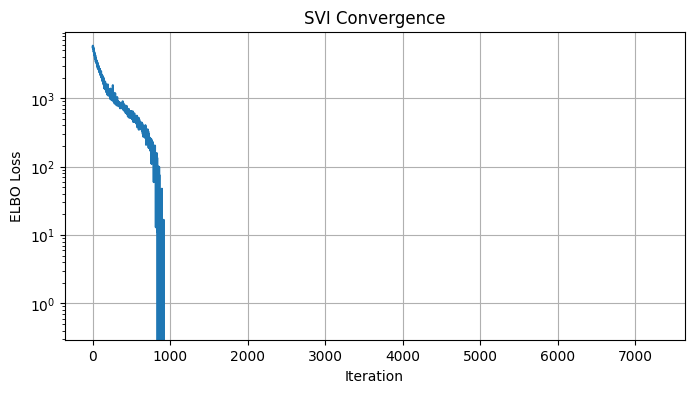

In [6]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from helpers.bgp_jax import RBFKernel

kernel = RBFKernel()

def model(
        time: jnp.array, 
        qhat: jnp.array,
        chi: float = 1e-6, 
        normalization=1e-8,  # Very small regularization
    ):
    num_time_steps = time.shape[0]
    numPODmodes = qhat.shape[0]
    
    # Get time scale
    time_range = time.max() - time.min()
    
    Ls = []
    Vars = []
    noises = []
    
    for i in range(numPODmodes):
        # Analyze data scale
        data_std = jnp.std(qhat[i])
        
        # For oscillatory data, we need small lengthscales
        # Start with a prior centered at ~1/20th of the time range
        lengthscale = numpyro.sample(f"lengthscale{i}", 
                                     dist.LogNormal(jnp.log(time_range/20), 1.0))
        Ls.append(lengthscale)
        
        # Variance based on data variance
        variance = numpyro.sample(f"variance{i}", 
                                 dist.LogNormal(jnp.log(data_std**2), 0.5))
        Vars.append(variance)
        
        # Small noise since data looks clean
        noise = numpyro.sample(f"noise{i}", 
                              dist.LogNormal(-8.0, 1.0))  # Very small noise
        noises.append(noise)
        
        # Compute kernel matrix
        K = kernel(time, time, lengthscale, variance)
        
        # Add tiny regularization for numerical stability
        K_noise = K + (noise + normalization) * jnp.eye(num_time_steps)
        
        # GP prior
        x = numpyro.sample(f"f{i}", dist.MultivariateNormal(jnp.zeros(num_time_steps), K_noise))
        
        # Likelihood
        with numpyro.plate(f"data{i}", num_time_steps):
            numpyro.sample(f"y{i}", dist.Normal(x, jnp.sqrt(noise)), obs=qhat[i])

# Create autoguide
guide = autoguide.AutoLowRankMultivariateNormal(model, rank=30)

# Setup optimizer - start with higher learning rate and decay
optimizer = Adam(step_size=0.01)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_sampled[:, None], 
                                  qhat=snapshots_compressed,
                                  chi=noiselevel,
                                  normalization=normalization
                                  )
    return svi_state, loss

# Training loop with patience
num_iterations = 20000  # More iterations
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Rest of your code remains the same...
# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=1000)
gp_samples = predictive(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")


# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

### Visualize

#### GP Predictions

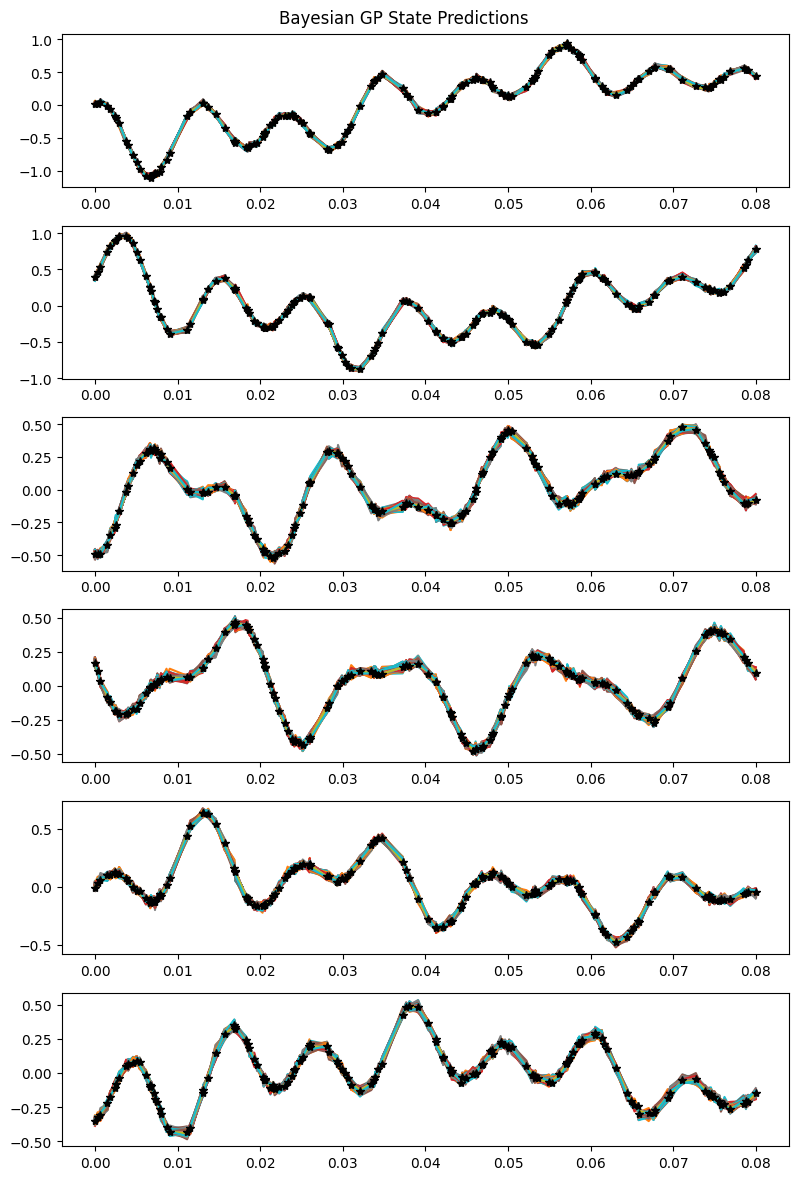

In [7]:
### Plot gp predictions
from helpers.bgp_jax import BayesianGP

fig, ax = plt.subplots(numPODmodes, 1, figsize = (8,12))


eval_points = [[] for i in range(numPODmodes)] 
eval_stds = [[] for i in range(numPODmodes)] 

for i in range(numPODmodes):
    gp_samples[f'Xi{i}'] = []

for i in range(num_pulls):
    rand_idx = random.randint(0, len(gp_samples['lengthscale0']))
    Ls = np.array([gp_samples[f'lengthscale{i}'][rand_idx] for i in range(numPODmodes)])
    Vs = np.array([gp_samples[f'variance{i}'][rand_idx] for i in range(numPODmodes)])
    Ns = np.array([gp_samples[f'noise{i}'][rand_idx] for i in range(numPODmodes)])

    gp = BayesianGP()
    gp.X_train = time_domain_sampled[:, None]
    for j in range(numPODmodes):
        fi = gp_samples[f'f{j}'][rand_idx]
        gp.y_train = snapshots_compressed[j]
        mean, std, _ = gp.predict_with_hypers(X_test=time_domain_sampled[:, None], lengthscale=Ls[j], variance=Vs[j], noise=Ns[j])
        mean_test, std_test, _ = gp.predict_with_hypers(X_test=time_domain_test[:, None], lengthscale=Ls[j], variance=Vs[j], noise=Ns[j])
        eval_points[j].append(mean_test)
        eval_stds[j].append(std_test)
        gp_samples[f'Xi{j}'].append(mean_test)
        ax[j].plot(time_domain_sampled, mean)
        ax[j].plot(time_domain_sampled, fi)

for i in range(numPODmodes):
    gp_samples[f'Xi{i}'] = np.array(gp_samples[f'Xi{i}'])
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')

fig.suptitle("Bayesian GP State Predictions")
fig.tight_layout()
plt.show()

#### GP Derivative Predictions

In [8]:
### Compute mean and std of each thing that we need

Ls_means = np.array([gp_samples[f'lengthscale{i}'].mean() for i in range(numPODmodes)])
Ls_stds = np.array([gp_samples[f'lengthscale{i}'].std() for i in range(numPODmodes)])
Ls_covs = np.array([jnp.cov(gp_samples[f'lengthscale{i}']) for i in range(numPODmodes)])
Vs_means = np.array([gp_samples[f'variance{i}'].mean() for i in range(numPODmodes)])
Vs_stds = np.array([gp_samples[f'variance{i}'].std() for i in range(numPODmodes)])
Vs_covs = np.array([jnp.cov(gp_samples[f'variance{i}']) for i in range(numPODmodes)])
Ns_means = np.array([gp_samples[f'noise{i}'].mean() for i in range(numPODmodes)])
Ns_stds = np.array([gp_samples[f'noise{i}'].std() for i in range(numPODmodes)])
Ns_covs = np.array([jnp.cov(gp_samples[f'noise{i}']) for i in range(numPODmodes)])
Fs_means = np.array([gp_samples[f'f{i}'].mean(axis=0) for i in range(numPODmodes)])

Ls_means.shape, Ls_stds.shape, Ls_covs.shape, Vs_means.shape, Vs_stds.shape, Vs_covs.shape, Ns_means.shape, Ns_stds.shape, Ns_covs.shape, Fs_means.shape

((6,), (6,), (6,), (6,), (6,), (6,), (6,), (6,), (6,), (6, 150))

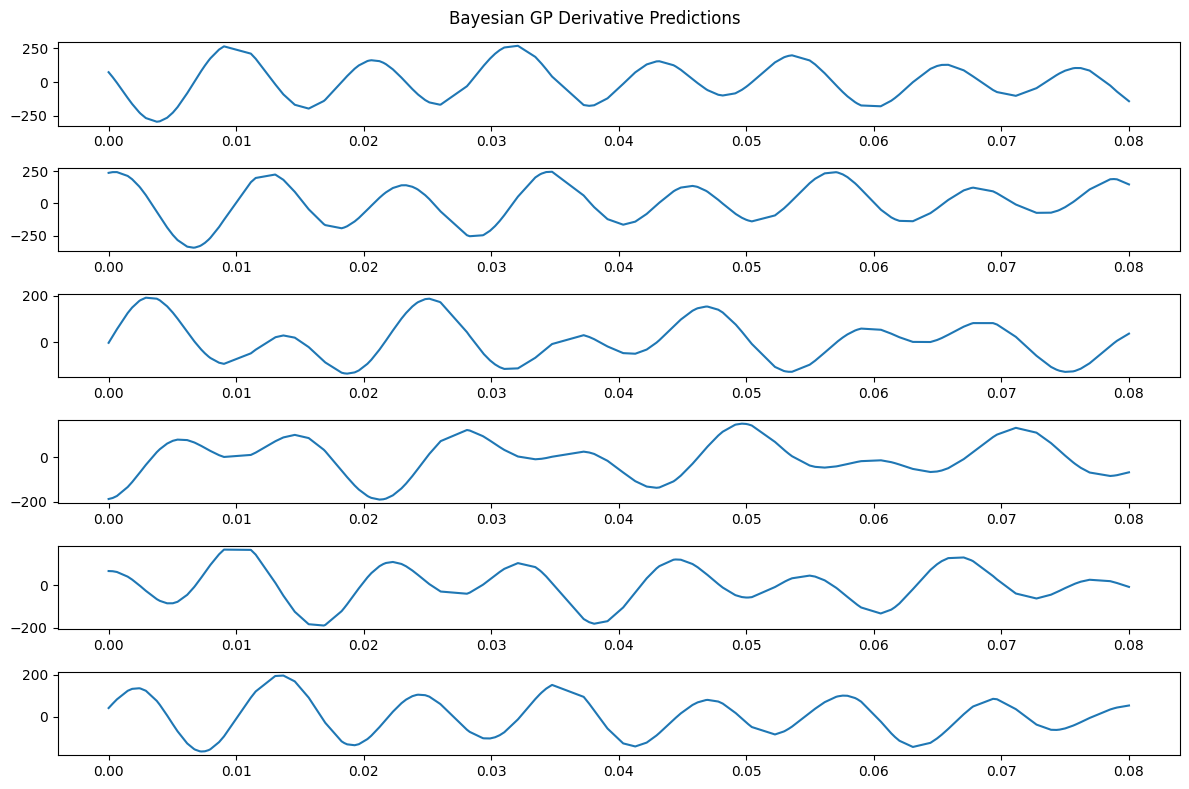

In [9]:
# Now let's check the derivative predictions
from helpers.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 
mu_z_modes = []
for i in range(numPODmodes):
    lengthscale = Ls_means[i]
    variance = Vs_means[i]
    Xi = Fs_means[i]
    # Cache inverse computation
    Kyy = get_c_phi(lengthscale, variance, time_domain_sampled[:,None], 1e-4)
    Kyy_inv = jnp.linalg.solve(Kyy, jnp.eye(time_domain_sampled.shape[0]))
    Ds = get_dash_c_phi(lengthscale, variance, time_domain_sampled[:,None]) @ Kyy_inv
    mu_z_j  = Ds @ Xi             # (num_time_steps,)
    mu_z_modes.append(mu_z_j)

mu_z_all = jnp.stack(mu_z_modes)               # (numPODmodes, num_time_steps)

fig, ax = plt.subplots(numPODmodes, 1, figsize=(12,8))
for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, mu_z_all[i])

fig.suptitle("Bayesian GP Derivative Predictions")
fig.tight_layout()
plt.show()

#### Bayesian Latent State

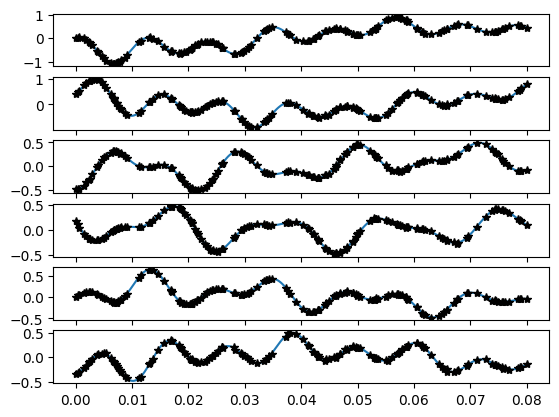

In [10]:
# Generate the Xi via inference
point_means = np.array(eval_points).mean(axis=1)
std_means = np.array(eval_stds).mean(axis=1)
point_means.shape, std_means.shape


fig, ax = plt.subplots(numPODmodes)
for i in range(numPODmodes):
    ax[i].plot(time_domain_test, point_means[i])
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')

gp_samples.keys()
plt.show()

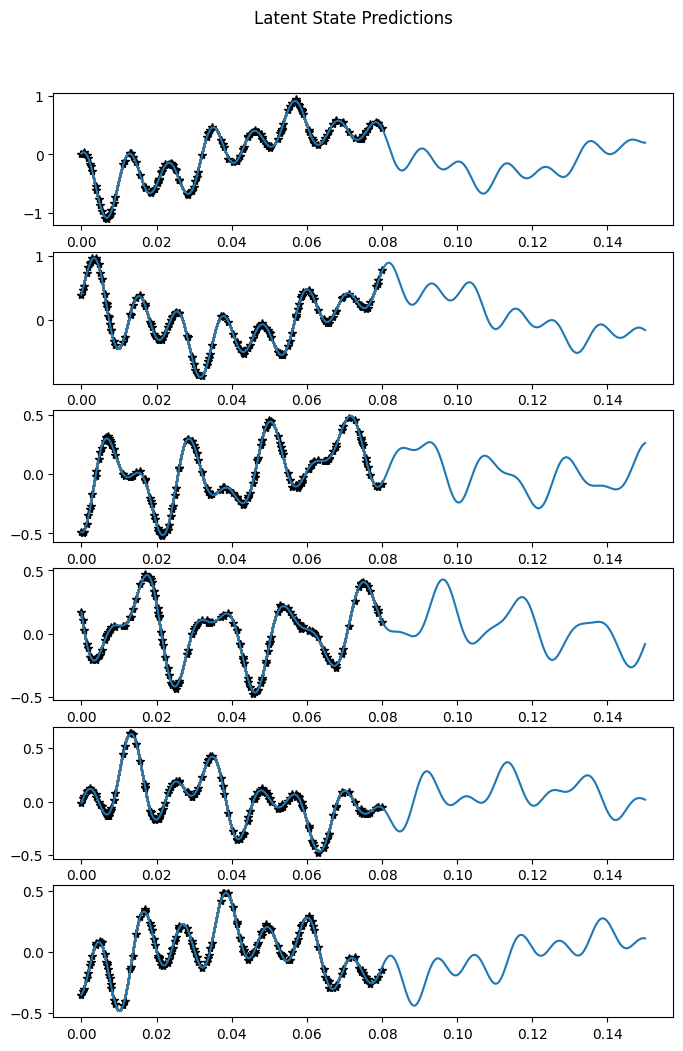

In [11]:
num_pulls = 250
trajs = []
deriv_trajs = []
Xss = []

time_m = time_domain_test

for i in range(num_pulls):
    rand_idx = random.randint(0, len(gp_samples['Xi0'])-1)
    Xs = np.array([gp_samples[f'Xi{i}'][rand_idx] for i in range(numPODmodes)])
    Xss.append(Xs)

fig, ax = plt.subplots(numPODmodes,1, figsize = (8, 12))

for i in range(len(Xss)):
    for j in range(numPODmodes):
        ax[j].plot(time_m, Xss[i][j], alpha =.2)

for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')
    ax[i].plot(time_domain, full_states_compressed[i])

fig.suptitle("Latent State Predictions", y=.95)
plt.show()

### Given these latent states how do we compute $\dot{\tilde{x}}$

$[\tilde{x} \quad \dot{\tilde{x}}] \sim \mathcal{N}([0, 0], [[K^{yy} \quad K^{yz}], [K^{zy} \quad K^{zz}]])]$

In [12]:
def flatten_time(t: jnp.ndarray) -> jnp.ndarray:
    """Return t with shape (n,) no matter if (n,), (n,1) or (1,n) was given."""
    return jnp.ravel(t)

def rbf_eval(lengthscale: float, variance: float, t: jnp.ndarray, t2: jnp.ndarray) -> jnp.ndarray:
    """Full n×n RBF kernel matrix K_ij = variance * exp(-(t_i-t_j)^2 / (2*ell^2))."""
    t = flatten_time(t)
    t2 = flatten_time(t2)
    diff = t[:, None] - t2[None, :]
    ell2 = lengthscale ** 2
    return variance * jnp.exp(-diff**2 / (2.0 * ell2))

K_yys = []
K_zys = []
K_zzs = []
for i in range(numPODmodes):
    tprime_minus_tprime = time_m[:, None] - time_m
    tprime_minus_t = time_m[:, None] - time_domain_sampled
    ell2 = Ls_means[i]**2
    rbf_yy = rbf_eval(Ls_means[i], Vs_means[i], time_domain_sampled, time_domain_sampled) 
    rbf_zy = rbf_eval(Ls_means[i], Vs_means[i], time_m, time_domain_sampled)
    rbf_zz = rbf_eval(Ls_means[i], Vs_means[i], time_m, time_m)
    K_yy = rbf_yy + 1e-5*np.diag(time_domain_sampled)
    K_zy = -(tprime_minus_t) * rbf_zy / ell2
    K_zz = (1- (tprime_minus_tprime**2 / ell2)) * rbf_zz / ell2 
    K_yys.append(K_yy)
    K_zys.append(K_zy)
    K_zzs.append(K_zz)

K_yys[0].shape, K_zys[0].shape, K_zzs[0].shape

((150, 150), (250, 150), (250, 250))

In [13]:
print(f"time_domain_sampled shape: {time_domain_sampled.shape}")
print(f"time_m shape: {time_m.shape}")
print(f"snapshots_compressed shape: {snapshots_compressed.shape}")
print(f"K_yy shape: {K_yys[0].shape}")
print(f"K_zy shape: {K_zys[0].shape}")

time_domain_sampled shape: (150,)
time_m shape: (250,)
snapshots_compressed shape: (6, 150)
K_yy shape: (150, 150)
K_zy shape: (250, 150)


In [50]:
def joint_gp_derivatives(Ls, Vs, time1, time2):
    for i in range(numPODmodes):
        ell2 = Ls[i]**2
        
        # Standard RBF kernels
        rbf_yy = rbf_eval(Ls[i], Vs[i], time1, time1) 
        rbf_zy = rbf_eval(Ls[i], Vs[i], time2, time1)
        rbf_zz = rbf_eval(Ls[i], Vs[i], time2, time2)
        
        # K_yy with noise term
        K_yy = rbf_yy + 1e-5 * np.eye(len(time1))  # Fixed: use eye instead of diag
        
        # K_zy: derivative kernel - note the correct difference computation
        diff_zy = time2[:, None] - time1[None, :]  # (250, 150)
        K_zy = -(diff_zy / ell2) * rbf_zy  # (250, 150)
        
        # K_zz: second derivative kernel
        diff_zz = time2[:, None] - time2[None, :]  # (250, 250)
        K_zz = ((1 - (diff_zz**2 / ell2)) / ell2) * rbf_zz  # (250, 250)
        
        K_yys.append(K_yy)
        K_zys.append(K_zy)
        K_zzs.append(K_zz)

    # Now the prediction should work
    mu_z = []
    cov_z = []
    for i in range(numPODmodes):
        w = jnp.linalg.solve(K_yys[i], snapshots_compressed[i])  # w shape: (150,)
        mu_zi = K_zys[i] @ w  # (250, 150) @ (150,) = (250,)
        mu_z.append(mu_zi)

        cov_zi = K_zzs[i] - K_zys[i] @ jnp.linalg.solve(K_yys[i], K_zys[i].T)
        cov_z.append(cov_zi)

    return jnp.array(mu_z), jnp.array(cov_z)  # Shape should be (6, 250)

In [51]:
K_yys = []
K_zys = []
K_zzs = []

for i in range(numPODmodes):
    ell2 = Ls_means[i]**2
    
    # Standard RBF kernels
    rbf_yy = rbf_eval(Ls_means[i], Vs_means[i], time_domain_sampled, time_domain_sampled) 
    rbf_zy = rbf_eval(Ls_means[i], Vs_means[i], time_m, time_domain_sampled)
    rbf_zz = rbf_eval(Ls_means[i], Vs_means[i], time_m, time_m)
    
    # K_yy with noise term
    K_yy = rbf_yy + 1e-5 * np.eye(len(time_domain_sampled))  # Fixed: use eye instead of diag
    
    # K_zy: derivative kernel - note the correct difference computation
    diff_zy = time_m[:, None] - time_domain_sampled[None, :]  # (250, 150)
    K_zy = -(diff_zy / ell2) * rbf_zy  # (250, 150)
    
    # K_zz: second derivative kernel
    diff_zz = time_m[:, None] - time_m[None, :]  # (250, 250)
    K_zz = ((1 - (diff_zz**2 / ell2)) / ell2) * rbf_zz  # (250, 250)
    
    K_yys.append(K_yy)
    K_zys.append(K_zy)
    K_zzs.append(K_zz)

# Now the prediction should work
mu_z = []
for i in range(numPODmodes):
    w = jnp.linalg.solve(K_yys[i], snapshots_compressed[i])  # w shape: (150,)
    mu_zi = K_zys[i] @ w  # (250, 150) @ (150,) = (250,)
    mu_z.append(mu_zi)
    
mu_z, cov_z = joint_gp_derivatives(Ls_means, Vs_means, time_domain_sampled, time_m)
mu_z2, cov_z2 = joint_gp_derivatives(Ls_means, Vs_means, time_m, time_m)

In [52]:
def compute_derivatives_fourth_order(snapshots, time_points):
    """
    Compute derivatives using 4th order finite differences.
    Works best for uniformly spaced time points.
    """
    n_modes, n_time = snapshots.shape
    derivatives = np.zeros_like(snapshots)
    dt = time_points[1] - time_points[0]  # Assumes uniform spacing
    
    # 4th order central differences for interior points
    for i in range(2, n_time - 2):
        derivatives[:, i] = (-snapshots[:, i+2] + 8*snapshots[:, i+1] - 
                            8*snapshots[:, i-1] + snapshots[:, i-2]) / (12 * dt)
    
    # Use 2nd order for near-boundary points
    for i in [1, n_time-2]:
        derivatives[:, i] = (snapshots[:, i+1] - snapshots[:, i-1]) / (2 * dt)
    
    # First and last points
    derivatives[:, 0] = (snapshots[:, 1] - snapshots[:, 0]) / dt
    derivatives[:, -1] = (snapshots[:, -1] - snapshots[:, -2]) / dt
    
    return derivatives

snapshots_compressed_derivatives = compute_derivatives_fourth_order(snapshots_compressed, time_domain_sampled)

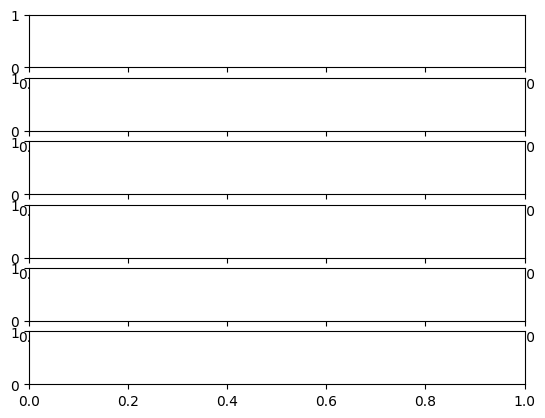

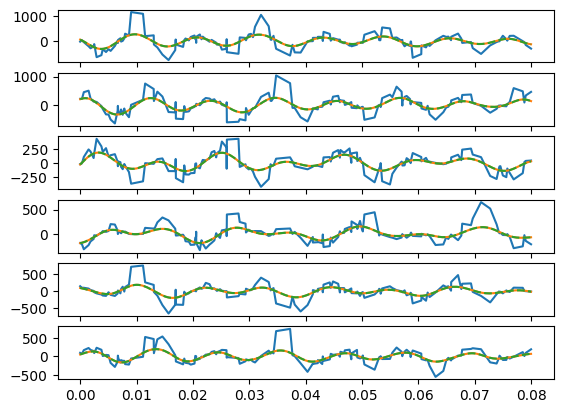

In [53]:
fig, ax = plt.subplots(numPODmodes)
for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, snapshots_compressed_derivatives[i])
    ax[i].plot(time_m, mu_z[i])
    ax[i].plot(time_m, mu_z2[i], linestyle = '--')

plt.show()

Covariance matrix for mode 0 has shape: (250, 250) and condition number: 28915138.0
Covariance matrix for mode 1 has shape: (250, 250) and condition number: 5425409.0
Covariance matrix for mode 2 has shape: (250, 250) and condition number: 7632020.5
Covariance matrix for mode 3 has shape: (250, 250) and condition number: 2802091.75
Covariance matrix for mode 4 has shape: (250, 250) and condition number: 9661286.0
Covariance matrix for mode 5 has shape: (250, 250) and condition number: 8129586.5


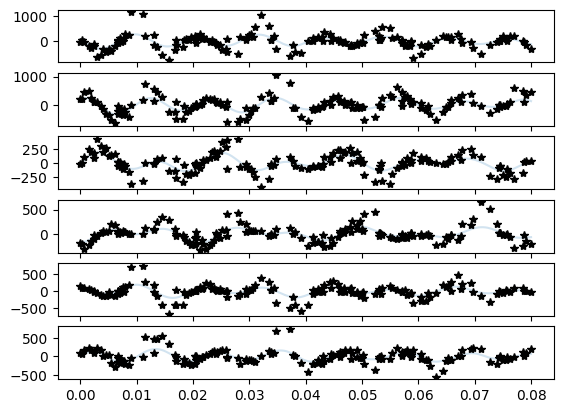

In [55]:
### Generate some samples from the distribution

fig, ax = plt.subplots(numPODmodes)

for i in range(numPODmodes):
    print(f"Covariance matrix for mode {i} has shape: {cov_z2[i].shape} and condition number: {np.linalg.cond(cov_z2[i])}")
    derivative_z = np.random.multivariate_normal(mean=mu_z2[i], cov=cov_z2[i])

    ax[i].plot(time_m, derivative_z, alpha = .2)
    ax[i].plot(time_domain_sampled, snapshots_compressed_derivatives[i], 'k*')
    # ax[i].plot(time_m, mu_z2[i], linestyle = '--')

plt.show()

In [18]:
from jax.scipy.special import gammaln
import jax.numpy as jnp

def binom(x, y):
  return jnp.exp(gammaln(x + 1) - gammaln(y + 1) - gammaln(x - y + 1))

def Quadraticckron(state):
    return jnp.concatenate(
                [state[i] * state[: i + 1] for i in range(state.shape[0])],
                axis=0,
            )

def Cubicckron(state):
    state2 = Quadraticckron(state)
    lens = binom(jnp.arange(2, len(state) + 2), 2).astype(int)
    return jnp.concatenate(
        [state[i] * state2[: lens[i]] for i in range(state.shape[0])],
        axis=0,
    )

def khatri_rao(a, b):
    return jnp.vstack([jnp.kron(a[:, k], b[:, k]) for k in range(b.shape[1])]).T

class JaxCompatibleModel(opinf.models.ContinuousModel):
    def __init__(self, operators, solver=None, *args, **kwargs):
        super().__init__(operators, solver, *args, **kwargs)
    
    def _assemble_data_matrix(self, states, inputs):
        """Assemble the data matrix for operator inference."""
        blocks = []
        for i in self._indices_of_operators_to_infer:
            op = self.operators[i]
            if isinstance(op, opinf.operators.ConstantOperator):
                block = jnp.ones((1, jnp.atleast_1d(states).shape[-1]))
            elif isinstance(op, opinf.operators.LinearOperator):
                block = jnp.atleast_2d(states)
            elif isinstance(op, opinf.operators.QuadraticOperator):
                block = Quadraticckron(jnp.atleast_2d(states))
            elif isinstance(op, opinf.operators.CubicOperator):
                block =Cubicckron(np.atleast_2d(states))
            elif isinstance(op, opinf.operators.InputOperator):
                block =jnp.atleast_2d(inputs)
            elif isinstance(op, opinf.operators.StateInputOperator):
                block =khatri_rao(jnp.atleast_2d(inputs), jnp.atleast_2d(states))
            else:
                print("idkK!!", type(op))
            blocks.append(block.T)

        return jnp.hstack(blocks)

(600, 150) (600, 150)


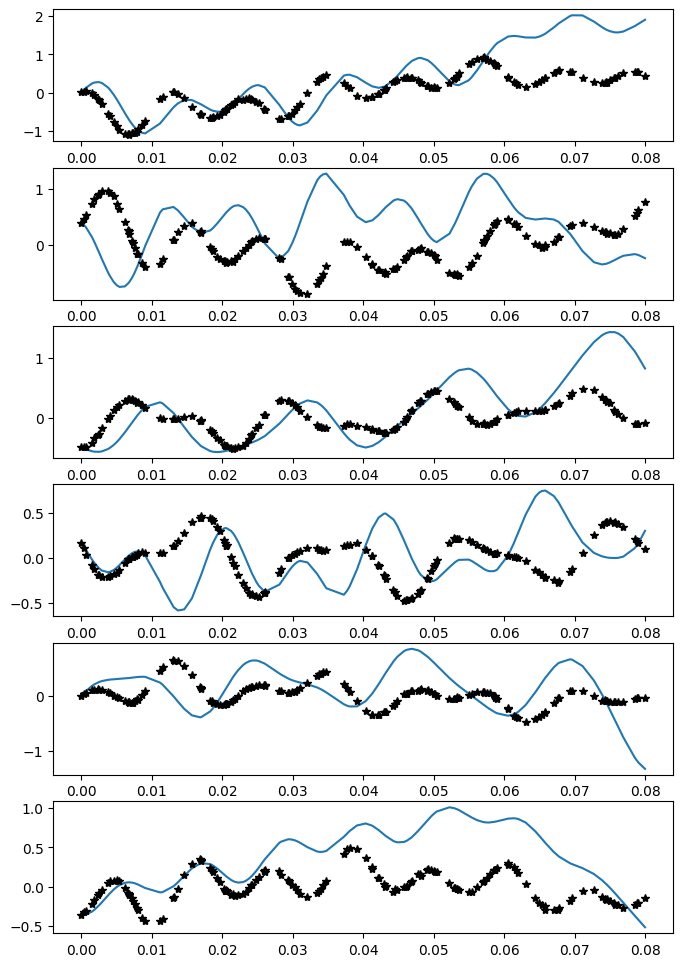

In [19]:
import numpy as np
import random
import time
import opinf

rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled),
    # model=opinf.models.ContinuousModel(
    #     operators="cAH",
    #     solver=opinf.lstsq.L2Solver(regularizer=1e-4),
    model=JaxCompatibleModel(
        operators='cAH',
        solver=opinf.lstsq.L2Solver(regularizer=1e-2),
    )
).fit(states=snapshots_sampled)

# Solve the ROM over a specified time domain. Make sure it's stable!
Q_rom = rom.predict(snapshots_sampled[:, 0], time_domain)

loaded_operator = np.load("operator.npy")
rom.model._extract_operators(loaded_operator)

# Plot predictions within training time domains
deter_pred = rom.model.predict(
    state0=snapshots_compressed[:, 0], 
    t=time_domain_sampled, 
)
deter_sol = rom.model.predict_result_


fig, ax = plt.subplots(numPODmodes,1, figsize = (8, 12))

for i in range(numPODmodes):
    ax[i].plot(deter_sol.t, deter_sol.y[i])
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')

plt.show()

In [20]:
Xs_means = np.stack(
    [gp_samples[f'Xi{i}'].mean(axis=0) for i in range(numPODmodes)],
    axis=0
)
Xs_covs = np.stack(
    [np.cov(gp_samples[f'Xi{i}'].T) for i in range(numPODmodes)],
    axis=0
)

def stable_cholesky(A, jitter=1e-6):
    """Compute Cholesky with automatic jitter for stability"""
    max_tries = 5
    for i in range(max_tries):
        try:
            L = jnp.linalg.cholesky(A + jitter * jnp.eye(A.shape[0]))
            return L
        except:
            jitter *= 10
    return jnp.linalg.cholesky(A + jitter * jnp.eye(A.shape[0]))

def stable_solve(A, b, jitter=1e-6):
    """Solve linear system with regularization"""
    return jnp.linalg.solve(A + jitter * jnp.eye(A.shape[0]), b)

<Figure size 640x480 with 0 Axes>

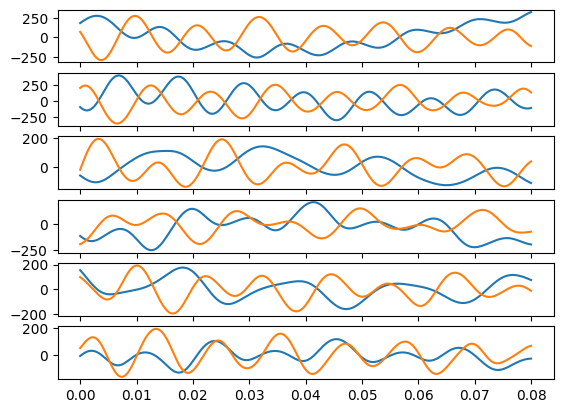

In [21]:
### Using this operator and our gp we should be able to test this shit out

plt.clf()
fig, ax = plt.subplots(numPODmodes)

O_samples = np.random.normal(loaded_operator, 0.1, size=loaded_operator.shape)
time = time_m[:, None]
num_time_steps = time.shape[0]


f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs=None) @ O_samples.T
mu_z = joint_gp_derivatives(Ls_means, Vs_means, time, time)

for i in range(numPODmodes):
    lengthscale = Ls_means[i]
    variance = Vs_means[i]
    
    Kyy = get_c_phi(lengthscale, variance, time, normalization)

    Kyy_inv = stable_solve(Kyy, jnp.eye(num_time_steps), jitter=normalization)
    Ds = get_dash_c_phi(lengthscale, variance, time) @ Kyy_inv
    CDashs = get_c_phi_dash(lengthscale, variance, time)
    DashCs = get_dash_c_phi(lengthscale, variance, time)
    CPhis = get_c_phi(lengthscale, variance, time, nugget=normalization)
    CDoubleDashs = get_c_phi_double_dash(lengthscale, variance, time)
    # Use Cholesky decomposition for more stable inverse
    CPhis_chol = stable_cholesky(CPhis, jitter=normalization)
    A = CDoubleDashs - DashCs @ jax.scipy.linalg.cho_solve((CPhis_chol, True), CDashs)
    mu_zi = mu_z[i]
    gamma = 1e1
    constraint_cov = A + gamma * jnp.eye(num_time_steps)

    f_Xi_ohat.T[i]

    ax[i].plot(time, f_Xi_ohat.T[i], label='f_Ohat')
    ax[i].plot(time, mu_zi, label='mu_z')

plt.show()

gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shap

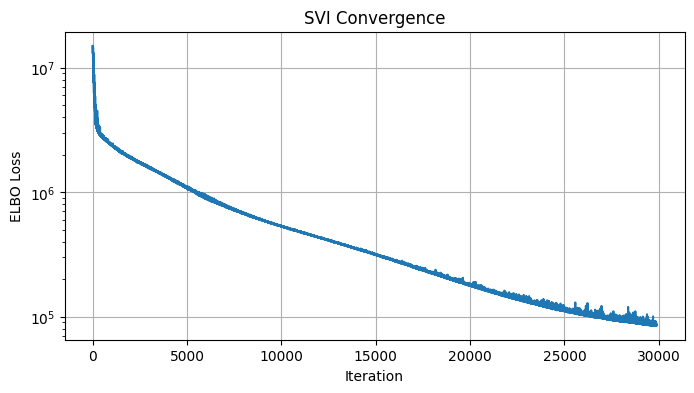

In [61]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from helpers.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 

kernel = RBFKernel()


def model(time, qhat, chi, normalization=1e-6):
    num_time_steps = time.shape[0]

    O_mean = np.random.random(((6, 28)))

    # O = numpyro.sample('O',
    #                 dist.Normal(jnp.zeros_like(O_mean), 5))
    
    # # Initialize array
    arr = np.zeros((6, 28))

    # Fill values
    arr[:, 0] = 1e0        # value for the 0th element
    arr[:, 1:6] = 1e3      # values for indices 1–5
    arr[:, 6:28] = 1e0     # values for indices 6–27

    # O = numpyro.sample('O',
    #                 dist.Normal(jnp.zeros_like(O_mean), arr))

    O = numpyro.sample('O',
                    dist.Normal(loaded_operator, arr))

    Xs = []
    Ls = []
    Vars = []
    noises = []
    Kyys = []
    
    for i in range(numPODmodes):
        # Priors for hyperparameters
        lengthscale = Ls_means[i]
        Ls.append(lengthscale)

        variance = Vs_means[i]
        Vars.append(variance)

        noise = Ns_means[i]
        noises.append(noise)
        Kyy = get_c_phi(lengthscale, variance, time, normalization)
        Kyys.append(Kyy)

        Xs.append(
            numpyro.sample(
                f"X{i}",
                dist.MultivariateNormal(loc=Xs_means[i], covariance_matrix=Xs_covs[i]+1e-4*jnp.eye(Xs_covs[i].shape[0])),
            )
        )
        
    f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs=None) @ O.T

    mu_z, cov_z = joint_gp_derivatives(Ls, Vars, time, time)
    
    for i in range(numPODmodes):
        # lengthscale = Ls[i]
        # variance = Vars[i]
        # Kyy = Kyys[i]
        # Xi = Xs[i]
        
        # Cache inverse computation
        # Kyy_inv = jnp.linalg.solve(Kyy, jnp.eye(num_time_steps))
        # Kyy_inv = stable_solve(Kyy, jnp.eye(num_time_steps), jitter=normalization)
        # Ds = get_dash_c_phi(lengthscale, variance, time) @ Kyy_inv
        # CDashs = get_c_phi_dash(lengthscale, variance, time)
        # DashCs = get_dash_c_phi(lengthscale, variance, time)
        # CPhis = get_c_phi(lengthscale, variance, time, nugget=normalization)
        # CDoubleDashs = get_c_phi_double_dash(lengthscale, variance, time)
        # Use Cholesky decomposition for more stable inverse
        # CPhis_chol = stable_cholesky(CPhis, jitter=normalization)
        # A = CDoubleDashs - DashCs @ jax.scipy.linalg.cho_solve((CPhis_chol, True), CDashs)
        mu_zi = mu_z[i]
        cov_zi = cov_z[i]
        gamma = 1e-1
        constraint_cov = cov_zi + gamma * jnp.eye(num_time_steps)

        print(f"gp derivative shape: {mu_zi.shape}, f_Xi_ohat shape: {f_Xi_ohat.T[i].shape}, constraint_cov shape: {constraint_cov.shape}")
        
        numpyro.sample(
            f'ode_constraint{i}',
            dist.MultivariateNormal(mu_zi, constraint_cov),
            obs=f_Xi_ohat.T[i]
        )

# You can also use more sophisticated guides like AutoLowRankMultivariateNormal
guide = autoguide.AutoLowRankMultivariateNormal(model, rank=200)

# Setup optimizer
optimizer = Adam(step_size=0.01)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time=time_m[:, None], 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_m[:, None], 
                                  qhat=snapshots_compressed,
                                  chi=noiselevel,
                                  normalization=normalization
                                  )
    return svi_state, loss

# Training loop
num_iterations = 100000  # Adjust as needed
losses = []
patience = 250
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=1000)
samples = predictive(rng_key,
                     time=time_m[:, None], 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

### Generate Predictions, Means, Medians and Percentiles via samples

In [66]:
Os = []
Xs = []
rom_solves = []

for i in range(num_pulls):
    O = samples['O'][i]
    Os.append(O)
    Xs.append(np.array([samples[f'X{j}'][i] for j in range(numPODmodes)]))

    rom.model._extract_operators(np.array(O))
    rom.model.predict(state0=snapshots_compressed[:, 0], t=time_m)
    if rom.model.predict_result_.y.shape[1] < time_m.size:
        print("Bad solve, skipping")
        continue
    rom_solves.append(rom.model.predict_result_.y)


Xs = np.array(Xs)
Os = np.array(Os)
rom_solves = np.array(rom_solves)


X_mean = Xs.mean(axis=0)
O_mean = Os.mean(axis=0)
rom_solves_mean = rom_solves.mean(axis=0)
X_median = np.median(Xs, axis=0)
O_median = np.median(Os, axis=0)
rom_solves_median = np.median(rom_solves, axis=0)
X_mean.shape, O_mean.shape, X_median.shape, O_median.shape

((6, 250), (6, 28), (6, 250), (6, 28))

<Figure size 640x480 with 0 Axes>

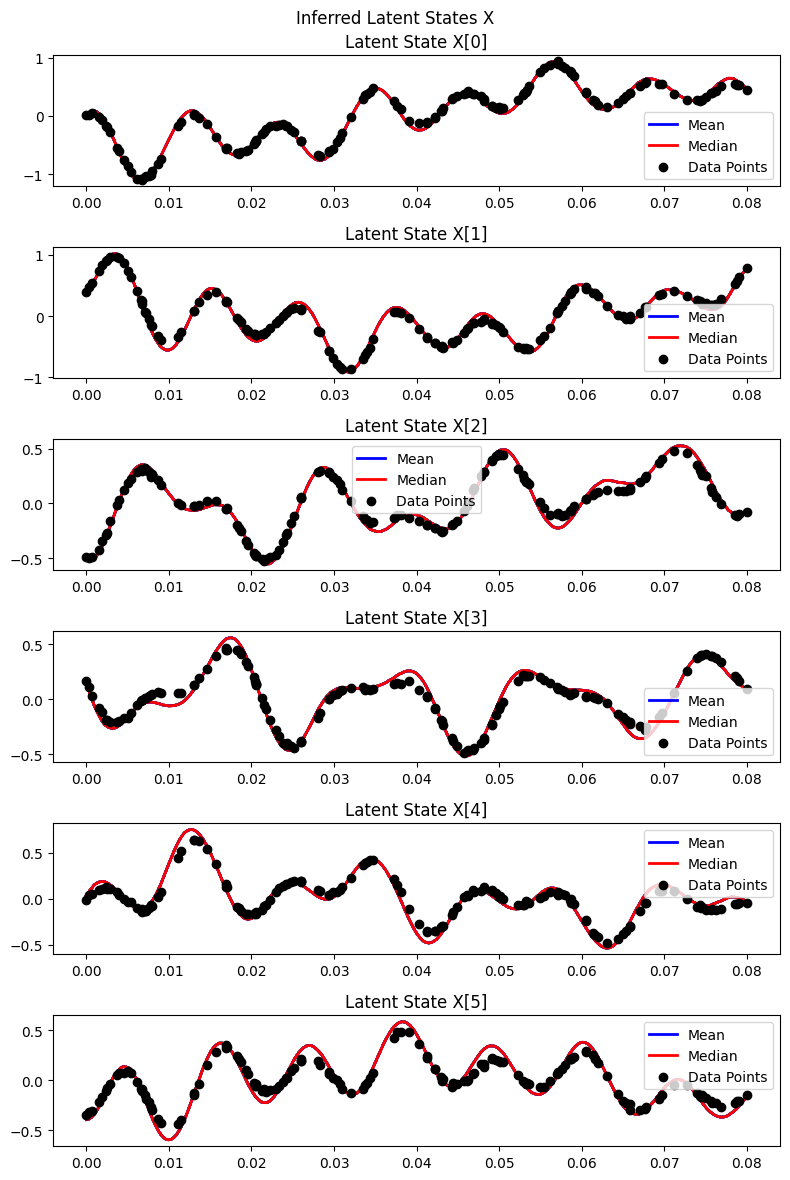

In [67]:
### Check Xs

plt.clf()
fig, ax = plt.subplots(numPODmodes,1, figsize = (8, 12))

for i in range(numPODmodes):
    for j in range(Xs.shape[0]):
        ax[i].plot(time_m, Xs[j, i], color='gray', alpha=0.3)
    ax[i].plot(time_m, X_mean[i], color='blue', label='Mean', linewidth=2)
    ax[i].plot(time_m, X_median[i], color='red', label='Median', linewidth=2)
    ax[i].scatter(time_domain_sampled, snapshots_compressed[i], color='black', label='Data Points', zorder=5)
    ax[i].set_title(f'Latent State X[{i}]')
    ax[i].legend()
plt.suptitle("Inferred Latent States X")
plt.tight_layout()
plt.show()

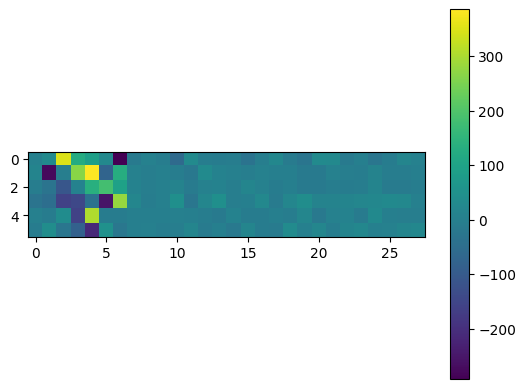

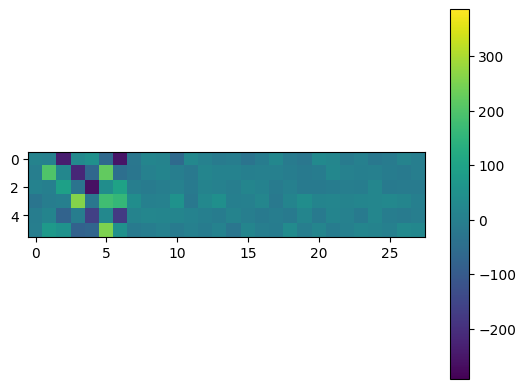

In [68]:
plt.imshow(loaded_operator, vmin = min(loaded_operator.min(), O_mean.min()), vmax = max(loaded_operator.max(), O_mean.max()))
plt.colorbar()
plt.show()
plt.imshow(O_mean, vmin = min(O_mean.min(), loaded_operator.min()), vmax = max(O_mean.max(), loaded_operator.max()))
plt.colorbar()
plt.show()

<Figure size 640x480 with 0 Axes>

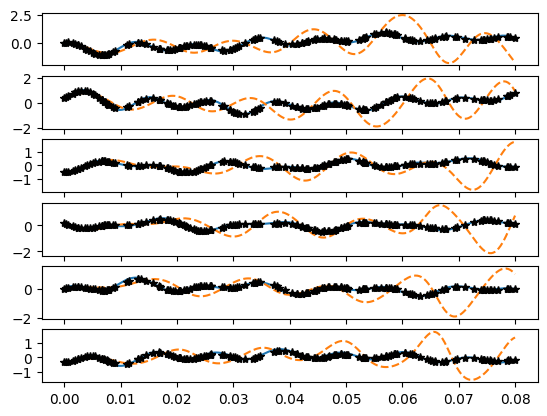

In [69]:
plt.clf()
fig, ax = plt.subplots(numPODmodes)

for i in range(numPODmodes):
    ax[i].plot(time_m, X_mean[i])
    ax[i].plot(time_m, rom_solves[i][i], linestyle='--')
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')



plt.show()